### Ensemble Learning [ Voting Classifier ]

Ensemble learning combines multiple base models to create a stronger predictive model.  
The Voting Classifier is a simple ensemble technique from scikit-learn that aggregates predictions from several classifiers.  
It supports two voting strategies:  
- Hard voting: majority class vote  
- Soft voting: average of predicted probabilities (requires probability=True for models like SVC)  

Implementing VotingClassifier on the Iris dataset using Logistic Regression, Decision Tree, and SVC as base estimators.  
We will also explore weighted soft voting and cross-validation.

In [196]:
import pandas as pd
import numpy as np
import seaborn as sns 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score 
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import load_iris 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

### Loading the Dataset
The Iris dataset contains 150 samples of three flower species (setosa, versicolor, virginica) with four numerical features (sepal_length, sepal_width, petal_length, petal_width).  
It is a classic multi-class classification problem often used to demonstrate machine learning algorithms.

In [198]:
data = sns.load_dataset('iris')
data.head(4)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa


### Label Encoding the Target Variable  
The 'species' column is categorical (string labels).  
LabelEncoder converts these strings into numeric values (0, 1, 2) required by scikit-learn classifiers.

In [200]:
# Initialize LabelEncoder and transform the species column
encoder = LabelEncoder()
data['species'] = encoder.fit_transform(data['species'])

# Verify encoding with a random sample
data.sample(3)

,sepal_length,sepal_width,petal_length,petal_width,species
127,6.1,3.0,4.9,1.8,2
37,4.9,3.6,1.4,0.1,0
132,6.4,2.8,5.6,2.2,2


### Pair Plot for Input feature 

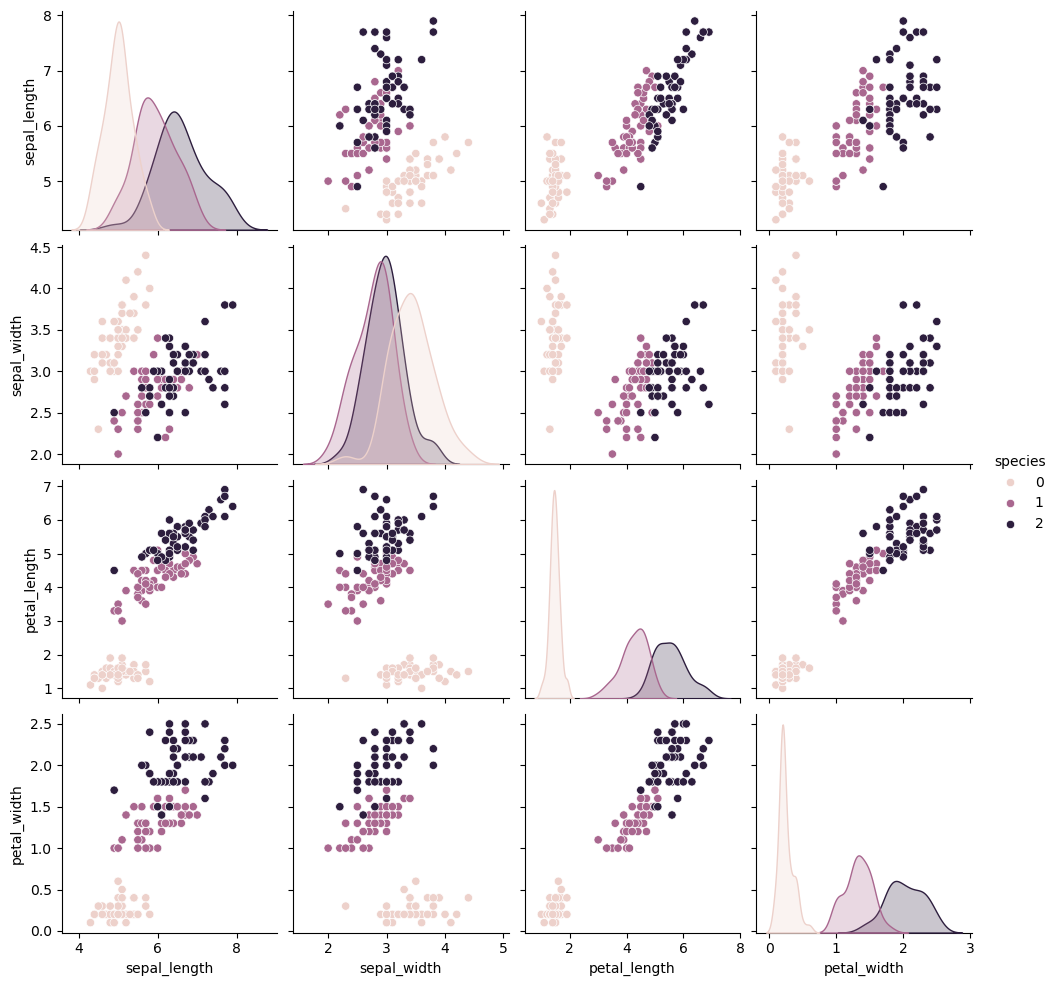

In [202]:
sns.pairplot(data,hue='species')
plt.show()

### Drop the third class
- work only with two classes 

In [204]:
new_df = data[data['species']!=0][['sepal_length','sepal_width','species']]

### Spliting Training and Testing Data 

In [206]:
# Prepare features (X) and target (y)
# Drop the target column from features
X = new_df.drop('species', axis=1)
y = new_df['species']

# Split into training and test sets (80/20 split)
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Voting Classifier - Soft Voting
- Soft voting averages the probability outputs of each base model and selects the class with the highest average probability.  
- It often performs better than hard voting when base models provide well-calibrated probabilities.

In [208]:
# Define base estimators with meaningful names
Logistic_Reg = LogisticRegression()
DecisionTree = DecisionTreeClassifier()
SVC_model = SVC(probability=True)  # probability=True required for soft voting

# Create the VotingClassifier with soft voting
voting_soft = VotingClassifier(
    estimators=[
        ('Logistic_Regresion', Logistic_Reg),
        ('Decision_tree', DecisionTree),
        ('SVC', SVC_model)
    ],
    voting='soft'
)

In [209]:
# Fit the ensemble model on training data
voting_soft.fit(X_train, y_train)

VotingClassifier(estimators=[('Logistic_Regresion', LogisticRegression()),
                             ('Decision_tree', DecisionTreeClassifier()),
                             ('SVC', SVC(probability=True))],
                 voting='soft')

### Score Evaluation
We predict on the test set and compute accuracy.  

In [211]:
# Generate predictions and evaluate
y_pred_soft = voting_soft.predict(X_test)
print("Accuracy Score for Soft Voting ::", accuracy_score(y_test, y_pred_soft))

Accuracy Score for Soft Voting :: 0.45


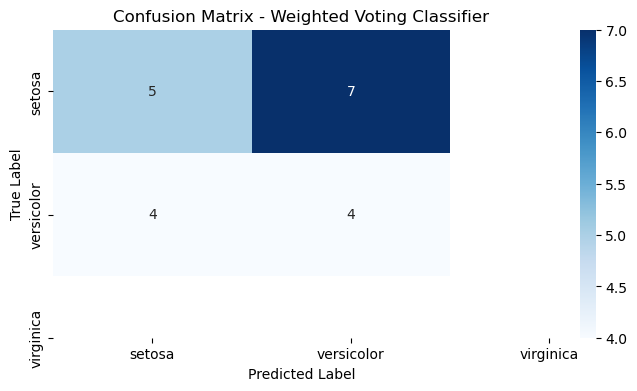

In [212]:
# Confusion Matrix Heatmap (using Voting soft predictions)
y_pred_weight = voting_soft.predict(X_test)
cm = confusion_matrix(y_test, y_pred_soft)

plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Confusion Matrix - Weighted Voting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#
---

### Voting Classifier - Weighted Voting
- Weighted voting allows assigning different importance to each base model via the 'weights' parameter.  
- Here we give higher weight to SVC (3) and Decision Tree (2) compared to Logistic Regression (1), as they may perform better on this data.

In [215]:
# Create weighted soft voting classifier
voting_weight = VotingClassifier(
    estimators=[
        ('Logistic_Regresion', Logistic_Reg),
        ('Decision_tree', DecisionTree),
        ('SVC', SVC_model)
    ],
    voting='soft',
    weights=[1, 2, 3]
)

In [216]:
# Fit the weighted ensemble
voting_weight.fit(X_train, y_train)

VotingClassifier(estimators=[('Logistic_Regresion', LogisticRegression()),
                             ('Decision_tree', DecisionTreeClassifier()),
                             ('SVC', SVC(probability=True))],
                 voting='soft', weights=[1, 2, 3])

### Score mEvaluation
We predict on the test set and compute accuracy.  

In [218]:
# Evaluate weighted model (using same predictions for comparison)
y_pred_weight = voting_weight.predict(X_test)
print("Accuracy Score for Weighted Voting ::", accuracy_score(y_test, y_pred_weight))

Accuracy Score for Weighted Voting :: 0.55


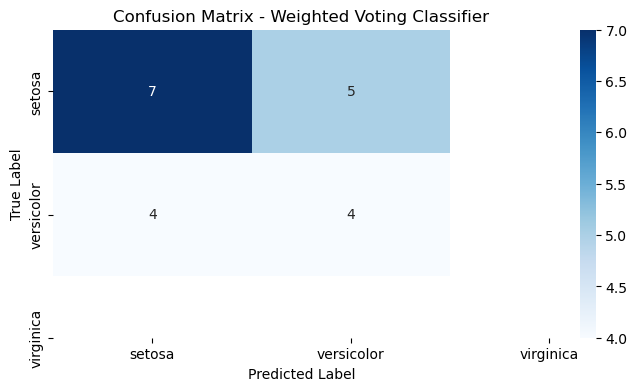

In [219]:
# Confusion Matrix Heatmap (using Weighted Voting predictions)
y_pred_weight = voting_weight.predict(X_test)
cm = confusion_matrix(y_test, y_pred_weight)

plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Confusion Matrix - Weighted Voting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [220]:
# Perform 5-fold cross-validation on the soft voting model using test data
# This gives a more robust estimate of performance
scores = cross_val_score(
    voting_soft,
    X_test,
    y_test,
    cv=5,
    scoring='accuracy'
)

print("Accuracy scores:", scores)
print("Mean Accuracy:", scores.mean())

Accuracy scores: [1.   0.25 0.25 1.   0.5 ]
Mean Accuracy: 0.6


#
---

### Voting Classifier – Hard Voting

- Hard voting combines the predictions of multiple base models by taking the majority vote of their predicted class labels.
- Each model casts a vote for a class, and the class with the highest number of votes is selected as the final prediction.
- It works well when the individual models are diverse and perform reasonably well on their own.

In [223]:
# Create the VotingClassifier with hard voting
voting_hard = VotingClassifier(
    estimators=[
        ('Logistic_Regresion', Logistic_Reg),
        ('Decision_tree', DecisionTree),
        ('SVC', SVC_model)
    ],
    voting='hard'
)

In [224]:
# Fit the weighted ensemble
voting_hard.fit(X_train, y_train)

VotingClassifier(estimators=[('Logistic_Regresion', LogisticRegression()),
                             ('Decision_tree', DecisionTreeClassifier()),
                             ('SVC', SVC(probability=True))])

### Score mEvaluation
We predict on the test set and compute accuracy.  

In [226]:
# Evaluate weighted model (using same predictions for comparison)
y_pred_hard = voting_hard.predict(X_test)
print("Accuracy Score for Weighted Voting ::", accuracy_score(y_test, y_pred_hard))

Accuracy Score for Weighted Voting :: 0.75


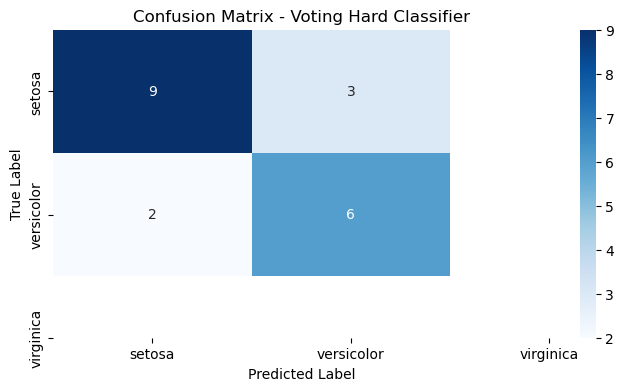

In [227]:
# Confusion Matrix Heatmap (using Voting Hard predictions)
y_pred_weight = voting_hard.predict(X_test)
cm = confusion_matrix(y_test, y_pred_hard)

plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Confusion Matrix - Voting Hard Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#
---

### Comparing Individual Models vs Voting Ensembles

In [230]:
# Calculate accuracies for all models (individual + ensembles)
model_accuracies = {}

# Individual base models
for name, model in [
    ('Logistic Regression', Logistic_Reg),
    ('Decision Tree', DecisionTree),
    ('SVC', SVC_model)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    model_accuracies[name] = accuracy_score(y_test, y_pred)

# Voting ensembles
model_accuracies['Hard Voting'] = accuracy_score(y_test, voting_hard.predict(X_test))
model_accuracies['Soft Voting'] = accuracy_score(y_test, voting_soft.predict(X_test))
model_accuracies['Weighted Voting'] = accuracy_score(y_test, voting_weight.predict(X_test))

print("Model Accuracies:")
for name, acc in model_accuracies.items():
    print(f"{name}: {acc:.4f}")

Model Accuracies:
Logistic Regression: 0.8000
Decision Tree: 0.4000
SVC: 0.8000
Hard Voting: 0.7500
Soft Voting: 0.4500
Weighted Voting: 0.5500


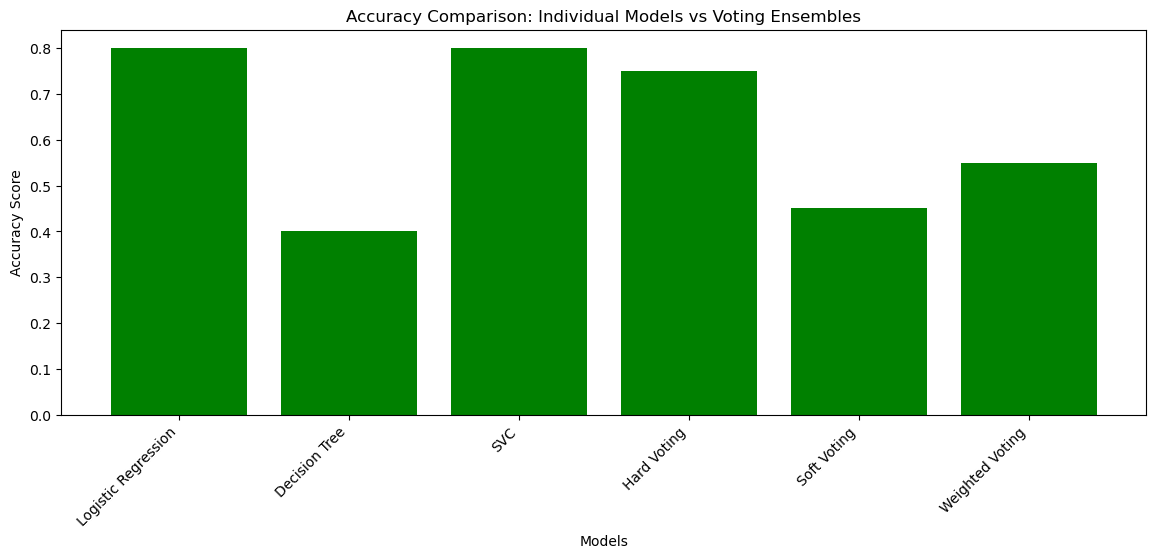

In [231]:
# Bar plot comparison
plt.figure(figsize=(14, 5))
names = list(model_accuracies.keys())
scores = list(model_accuracies.values())

bars = plt.bar(names, scores,color='green')
plt.title('Accuracy Comparison: Individual Models vs Voting Ensembles')
plt.ylabel('Accuracy Score')
plt.xlabel('Models')
plt.xticks(rotation=45, ha='right')
plt.show()